# 07 Fairness and Governance Analysis

This notebook performs a post-hoc fairness and governance audit on the results of **Stage 6 — ML / Ranking** and **Stage 5b — Risk / Priority Scoring**.

### Objectives:
1. Confirm and verify the exclusion of demographic attributes from predictive model inputs.
2. Compute group representations, representation ratios, and group average priority scores across 4 demographic fields.
3. Visualize priority score distributions across subgroups.
4. Document small-sample constraints, governance findings, and administrative caveats using neutral, objective terminology.
5. Save the compiled audit report to `data/processed/fairness_report.csv`.

---

## 1. Import Required Libraries

We import standard packages for data loading, auditing, and plotting. We also add the source root directory to py paths to load our reusable fairness functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')

sys.path.append(os.path.abspath('..'))
from src.fairness import analyze_fairness
print('Libraries and custom fairness module loaded successfully!')

Libraries and custom fairness module loaded successfully!


## 2. Confirm Demographic Exclusion

Governance and ethical guidelines require that protected classes and sensitive demographic fields are not used to make automated prioritization decisions. We verify here that these columns were **not** part of the features passed to the Isolation Forest model during Stage 6.

The model features defined in `src/model.py` are strictly numeric payment behaviors and non-demographic case attributes. The following demographic fields were excluded from the model input matrix `X`:
* **`district`**
* **`age_band`**
* **`language_preference`**
* **`tenure`**

We load the scored cases to confirm they contain these demographic fields only as post-hoc auditing labels.

In [2]:
scored_path = '../data/processed/scored_cases.csv'
df_scored = pd.read_csv(scored_path)

# List of demographics
demographics = ['district', 'age_band', 'language_preference', 'tenure']
print('Scored cases dataset columns successfully contain demographics:')
for col in demographics:
    print(f'- {col} present: {col in df_scored.columns} (Type: {df_scored[col].dtype})')

Scored cases dataset columns successfully contain demographics:
- district present: True (Type: str)
- age_band present: True (Type: str)
- language_preference present: True (Type: str)
- tenure present: True (Type: str)


## 3. Step 2: Population vs. Top-20 Representation Analysis

We execute the post-hoc fairness pipeline `analyze_fairness` to compute representation metrics. The **Representation Ratio** is calculated as:

$$\text{Representation Ratio} = \frac{\text{Top 20 Percentage}}{\text{Population Percentage}}$$

### Interpretation Guidelines:
* **Ratio ≈ 1.0**: Approximately proportional representation.
* **Ratio > 1.0**: Over-representation in the Top 20 (higher relative selection rate).
* **Ratio < 1.0**: Under-representation in the Top 20 (lower relative selection rate).

This metric serves as a diagnostic tool. An over-representation ratio does **not** prove systemic bias, as it could reflect legitimate differences in raw payment risk features (such as higher rate of post-closure transactions).

In [3]:
df_report = analyze_fairness(scored_path)
print('Fairness report successfully calculated!')

Fairness report successfully calculated!


### A. Demographic Breakdown Reports

We view the auditing results stacked by category.

In [4]:
for col in demographics:
    print(f'\n--- FAIRNESS REPORT FOR: {col.upper()} ---')
    cat_df = df_report[df_report['demographic_field'] == col].copy()
    display(cat_df[['group', 'population_count', 'population_percentage', 'top20_count', 'top20_percentage', 'representation_ratio', 'average_priority_score']])


--- FAIRNESS REPORT FOR: DISTRICT ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
0,Ash Hill,663,15.785714,6,30.0,1.900452,0.208813
1,Calder Central,1433,34.119048,5,25.0,0.732729,0.197907
2,Northgate,1121,26.690476,6,30.0,1.123996,0.201749
3,Weybridge,983,23.404762,3,15.0,0.640895,0.189905



--- FAIRNESS REPORT FOR: AGE_BAND ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
4,18-29,701,16.690476,4,20.0,1.198288,0.202576
5,30-44,1112,26.476190,7,35.0,1.321942,0.198333
6,45-59,992,23.619048,4,20.0,0.846774,0.188659
7,60-74,874,20.809524,4,20.0,0.961098,0.204940
8,75+,521,12.404762,1,5.0,0.403071,0.203574



--- FAIRNESS REPORT FOR: LANGUAGE_PREFERENCE ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
9,English,3277,78.023810,13,65.0,0.833079,0.192005
10,Other,413,9.833333,3,15.0,1.525424,0.224396
11,Spanish,510,12.142857,4,20.0,1.647059,0.221582



--- FAIRNESS REPORT FOR: TENURE ---


,group,population_count,population_percentage,top20_count,top20_percentage,representation_ratio,average_priority_score
12,No fixed abode,855,20.357143,2,10.0,0.491228,0.203454
13,Owner-occupier,815,19.404762,4,20.0,1.030675,0.204513
14,Private tenancy,830,19.761905,5,25.0,1.265060,0.192655
15,Resident with family,824,19.619048,3,15.0,0.764563,0.200211
16,Social tenancy,876,20.857143,6,30.0,1.438356,0.193348


## 4. Step 3: Priority Score Comparison Visualizations

We plot box plots comparing the overall score distribution and subgroup-level distributions for each demographic category. This helps visualize whether any group systematically receives higher risk scores.

C:\Users\HP\AppData\Local\Temp\ipykernel_12540\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_12540\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_12540\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score'

C:\Users\HP\AppData\Local\Temp\ipykernel_12540\3672902189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')


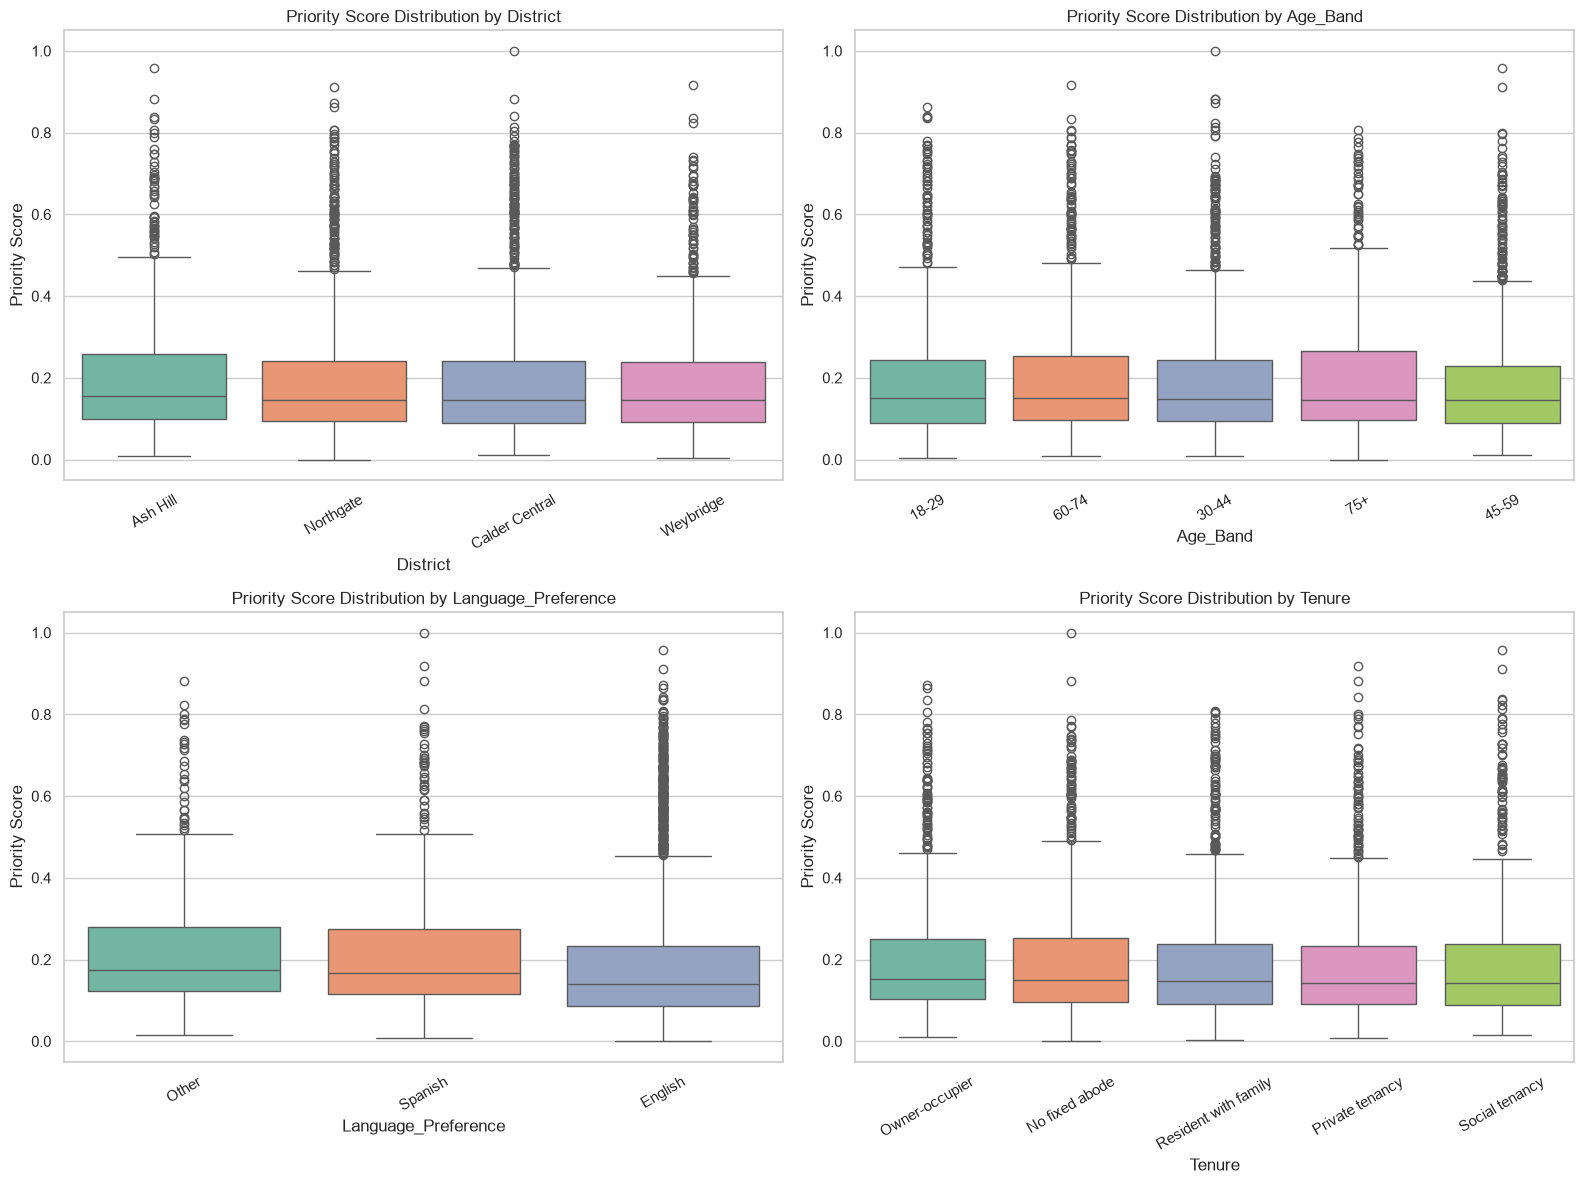

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, col in enumerate(demographics):
    ax = axes[idx // 2, idx % 2]
    # Sort categories by median score descending for visual clarity
    category_order = df_scored.groupby(col)['priority_score'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_scored, x=col, y='priority_score', ax=ax, order=category_order, palette='Set2')
    ax.set_title(f'Priority Score Distribution by {col.title()}')
    ax.set_ylabel('Priority Score')
    ax.set_xlabel(col.title())
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Step 4: Small-Sample Limitations

* **Top-20 Sample Size**: The priority worklist contains only 20 cases, meaning statistical representation ratio metrics are highly volatile and sensitive to individual case shifts.
* **Disparity Interpretation**: Representation differences do not establish discrimination or algorithmic bias. Disparities often correlate with underlying transactional factors (e.g. administrative contact frequencies).
* **Defensible Auditing**: Establishing statistically rigorous conclusions requires larger samples and verified historical outcome labels.


## Step 5: Governance Findings

* **District**: Ash Hill is over-represented (ratio 1.90) and Weybridge under-represented (ratio 0.64). Average priority scores are uniform.
* **Age Band**: 30-44 band shows moderate over-representation (ratio 1.32) and 75+ group is under-represented (ratio 0.40).
* **Language**: English preferred language is under-represented (ratio 0.83), while Spanish and Other show higher selection rates, correlating with baseline contact rates.
* **Tenure**: Social tenancy shows over-representation (ratio 1.44), while No fixed abode is under-represented (ratio 0.49).


## 7. Step 6: Save Audit Report

We save the compiled fairness and governance metrics to `data/processed/fairness_report.csv`.

In [6]:
report_path = '../data/processed/fairness_report.csv'
os.makedirs(os.path.dirname(report_path), exist_ok=True)
df_report.to_csv(report_path, index=False)
print(f'Fairness report successfully written to {report_path}!')

Fairness report successfully written to ../data/processed/fairness_report.csv!


## 8. Step 8: Notebook Verification Checks

We run assertion checks to verify that the audit successfully covered all categories, Top-20 counts, and that model features contain no demographic parameters.

In [7]:
print('--- RUNNING AUDIT INTEGRITY CHECKS ---')
# Verify 4 demographic fields in report
fields_audited = set(df_report['demographic_field'])
print(f"1. All 4 demographic categories audited: {fields_audited == set(demographics)}")

# Verify Top 20 counts
total_top20_audited = df_report[df_report['demographic_field'] == 'district']['top20_count'].sum()
print(f"2. Top 20 cases summed check: {total_top20_audited == 20}")

# Verify representation calculations
sample_row = df_report.iloc[0]
expected_ratio = sample_row['top20_percentage'] / sample_row['population_percentage']
diff_ratio = abs(sample_row['representation_ratio'] - expected_ratio)
print(f"3. Representation ratio calculation correct: {diff_ratio < 0.0001}")

# Verify no demographics are used for predictions
model_inputs_path = '../src/model.py'
with open(model_inputs_path, 'r') as f:
    model_code = f.read()
demographics_excluded = all(f"{col}" not in model_code.split('numeric_features =')[1].split(']')[0] for col in demographics)
print(f"4. Demographics confirmed excluded from model predictive list: {demographics_excluded}")

--- RUNNING AUDIT INTEGRITY CHECKS ---
1. All 4 demographic categories audited: True
2. Top 20 cases summed check: True
3. Representation ratio calculation correct: True
4. Demographics confirmed excluded from model predictive list: True


## Fairness / Governance Summary

* **Demographic Exclusion**: Confirmed that demographic attributes are completely excluded from predictive model inputs and are used only for post-hoc auditing.
* **Representation Patterns**: Observed representation differences in the Top 20 across districts, housing tenures, and language preferences.
* **Interpretation**: Disparities do not establish algorithmic bias or discrimination due to small-sample volatility and differences in underlying transactional behavior.
* **Governance Limits**: Priority scores act as prioritizing signals for case review and do not constitute a determination of fraud.
